# importing libraries , connecting google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder

# Preparing the Dataset and finding correlations

In [ ]:
drug= pd.read_csv("/content/drive/MyDrive/drug abuser.csv")

In [ ]:
drug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 60 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Case_ID                               227 non-null    object 
 1   Age                                   227 non-null    int64  
 2   Marital_Status                        227 non-null    object 
 3   Employment_Status                     227 non-null    object 
 4   Income Level                          227 non-null    object 
 5   Health Index                          227 non-null    int64  
 6   Smoking                               227 non-null    object 
 7   psychological_disorder                227 non-null    object 
 8   taken_drugs                           227 non-null    object 
 9   dropped_motivation_to_working         227 non-null    object 
 10  absence_from_work                     227 non-null    object 
 11  find_exotic_tools  

In [ ]:
drug.head(3)

,Case_ID,Age,Marital_Status,Employment_Status,Income Level,Health Index,Smoking,psychological_disorder,taken_drugs,dropped_motivation_to_working,...,inablity_to_estimate,dryness_or_Redness,Fatigue_pallor,slow_reactions,difficulty_controlling_emotions,Deterioration_of_physical_appearance,Weighted_Stress_Index,Risk_of_Legal_Issues,Risk_Factor_Score,Drug_or_not
0,AHU235,20,Single,Unemployed,Low Income,2,Yes,No,No,Yes,...,Yes,Yes,Yes,No,Yes,Yes,29.026112,7,2.113028,Yes
1,AHU249,19,Married,Self-employed,Low Income,3,Yes,No,Yes,Yes,...,No,No,No,Yes,No,Yes,18.493526,9,1.911381,Yes
2,AHU123,27,Single,Part-time employed,Lower Middle Income,1,Yes,Yes,Yes,Yes,...,No,No,No,Yes,Yes,Yes,11.990000,3,2.059167,No


In [ ]:
drug['Risk_Factor_Score'] = drug['Risk_Factor_Score'].round(2)
drug['Weighted_Stress_Index'] = drug['Weighted_Stress_Index'].round(2)

In [ ]:
cat_columns = drug.select_dtypes(['object']).columns



label_encoder = LabelEncoder()
drug[cat_columns] = drug[cat_columns].apply(LabelEncoder().fit_transform)
drug.head()

,Case_ID,Age,Marital_Status,Employment_Status,Income Level,Health Index,Smoking,psychological_disorder,taken_drugs,dropped_motivation_to_working,...,inablity_to_estimate,dryness_or_Redness,Fatigue_pallor,slow_reactions,difficulty_controlling_emotions,Deterioration_of_physical_appearance,Weighted_Stress_Index,Risk_of_Legal_Issues,Risk_Factor_Score,Drug_or_not
0,133,20,1,4,0,2,1,0,0,1,...,1,1,1,0,1,1,29.03,7,2.11,1
1,147,19,0,2,0,3,1,0,1,1,...,0,0,0,1,0,1,18.49,9,1.91,1
2,21,27,1,1,1,1,1,1,1,1,...,0,0,0,1,1,1,11.99,3,2.06,0
3,5,21,1,3,0,3,0,0,0,0,...,1,0,0,1,0,1,10.03,0,1.90,0
4,42,18,1,3,0,1,1,0,0,1,...,1,1,1,1,1,1,28.19,5,2.06,1


In [ ]:
used_columns = ['Drug_or_not','Smoking','psychological_disorder','sleeping_habits','decreased_social_interaction','lying','difficulty_speaking_expressing','irritable_mood'
,'hallucinations','unjustified_anxiety_fear','Nausea','feeling_of_superiority','suspension_in_issues','memory_impairment','aggressive_behavior','hand_shakes','suicidal_behavior'
,'distracted_and_absent_minded','difficulty_to_relaxing','difficulty_controlling_emotions','Weighted_Stress_Index','Age','headache','Risk_Factor_Score']


drug_test = drug.loc[:, used_columns].copy()

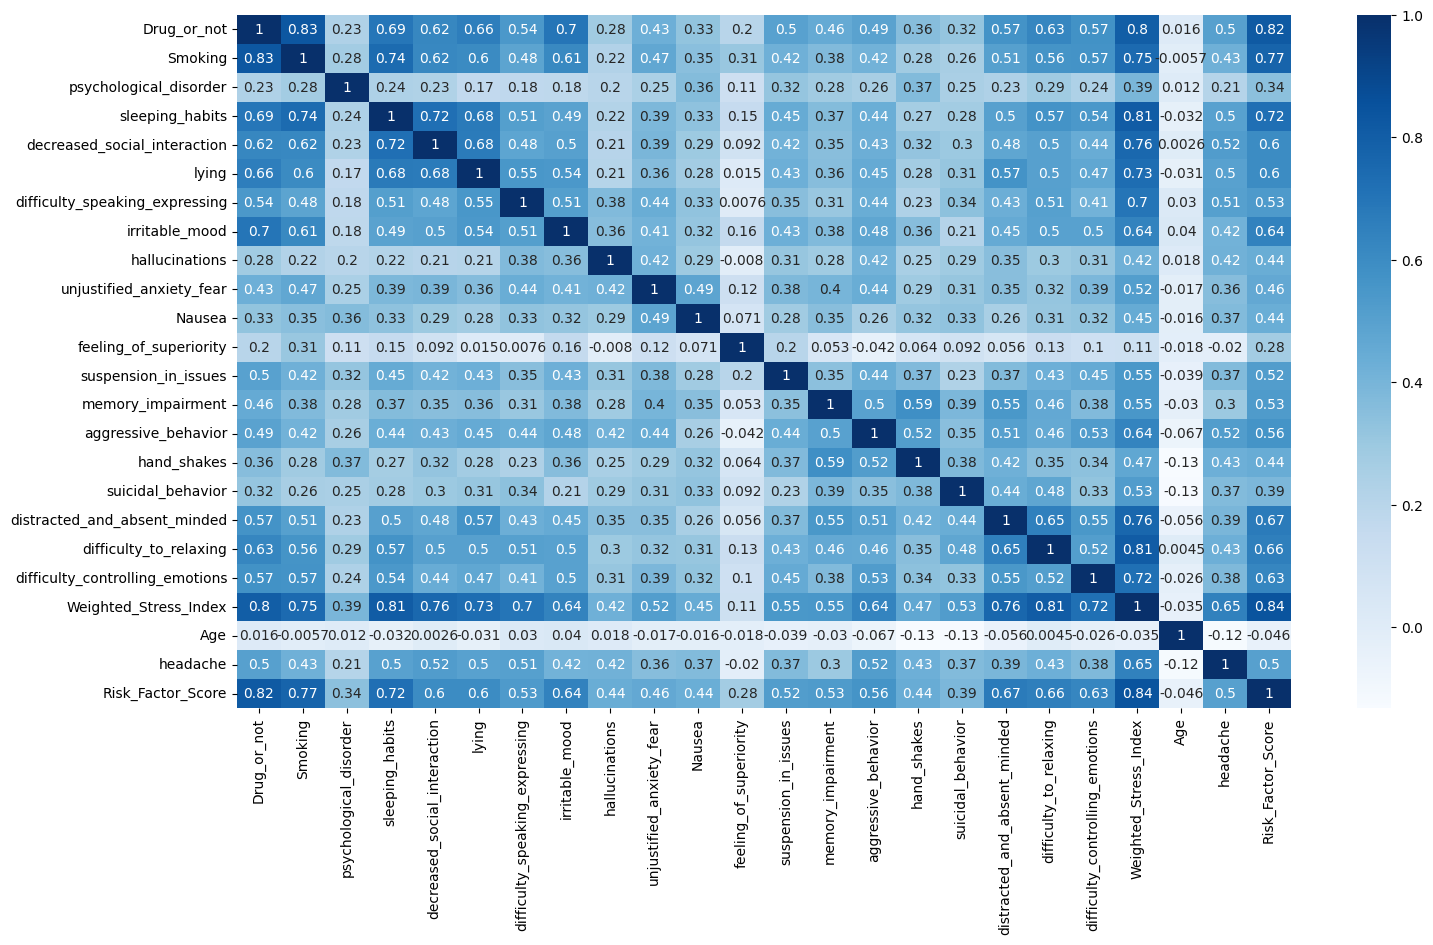

In [ ]:
plt.figure(figsize=(17, 9))
dataplot = sb.heatmap(drug_test.corr(), cmap="Blues", annot=True)

plt.show()

# insight visualizations

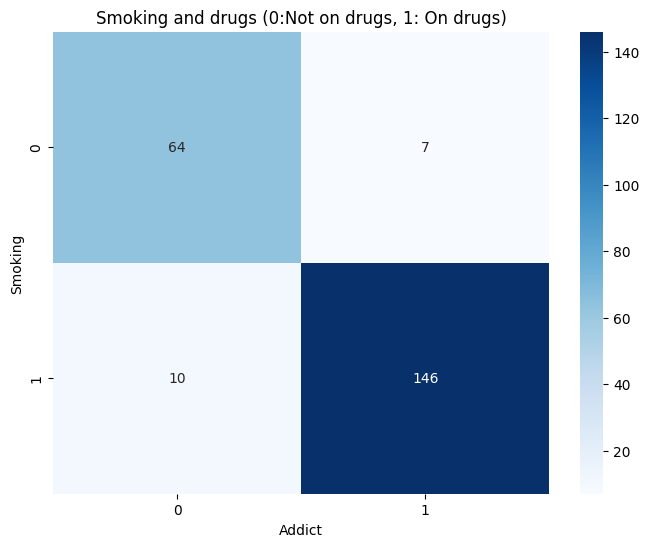

In [ ]:
table = pd.crosstab(drug_test['Smoking'], drug_test['Drug_or_not'])


plt.figure(figsize=(8, 6))
sb.heatmap(table, annot=True, cmap='Blues', fmt='d')
plt.title('Smoking and drugs (0:Not on drugs, 1: On drugs)')
plt.xlabel('Addict')
plt.ylabel('Smoking')
plt.show()

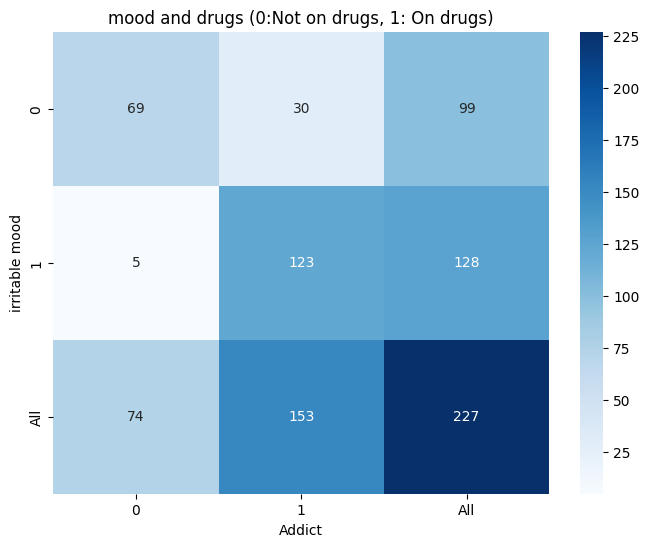

Drug_or_not,0,1,All
irritable_mood,,,
0,69,30,99
1,5,123,128
All,74,153,227


In [ ]:
table = pd.crosstab(drug_test['irritable_mood'], drug_test['Drug_or_not'],margins= True)


plt.figure(figsize=(8, 6))
sb.heatmap(table, annot=True, cmap='Blues', fmt='d')
plt.title('mood and drugs (0:Not on drugs, 1: On drugs)')
plt.xlabel('Addict')
plt.ylabel('irritable mood')
plt.show()
table

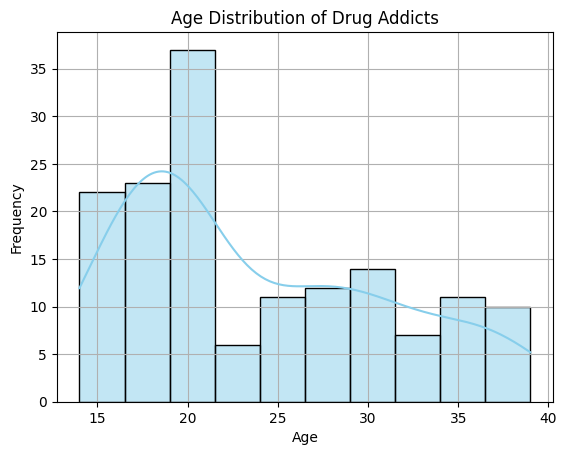

In [ ]:
drug_addicts = drug_test[drug_test['Drug_or_not'] == 1]


sb.histplot(data=drug_addicts, x='Age', bins=10, kde=True, color='skyblue')
plt.title('Age Distribution of Drug Addicts')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

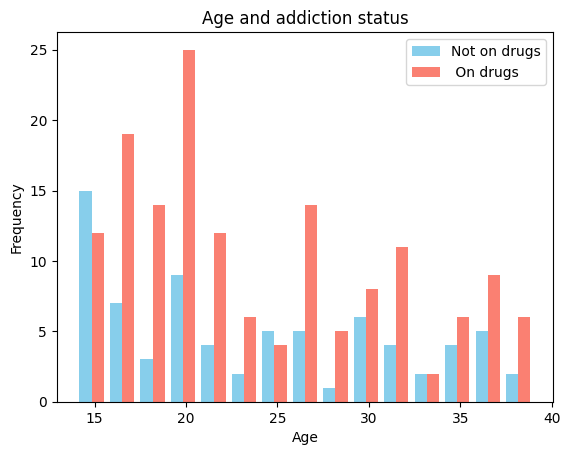

In [ ]:
drug_labels = ['Not on drugs', ' On drugs']

drug_data2 = [drug_test[drug_test['Drug_or_not'] == 0]['Age'],
             drug_test[drug_test['Drug_or_not'] == 1]['Age']]

plt.hist(drug_data2, bins=15, color=['skyblue', 'salmon'], label=drug_labels)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age and addiction status')
plt.legend()

plt.show()

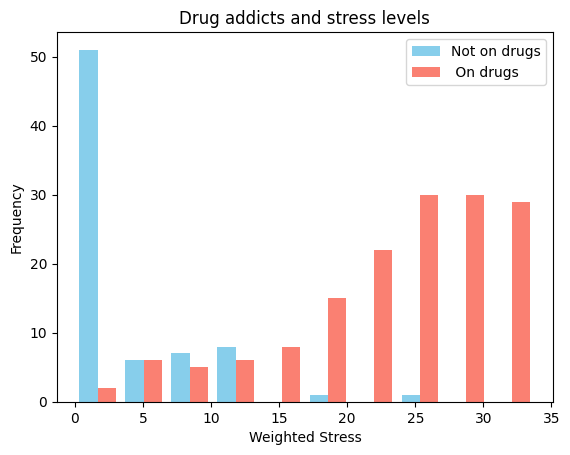

In [ ]:
drug_labels = ['Not on drugs', ' On drugs']


drug_data = [drug_test[drug_test['Drug_or_not'] == 0]['Weighted_Stress_Index'],
             drug_test[drug_test['Drug_or_not'] == 1]['Weighted_Stress_Index']]

plt.hist(drug_data, bins=10, color=['skyblue', 'salmon'], label=drug_labels)

plt.xlabel('Weighted Stress')
plt.ylabel('Frequency')
plt.title('Drug addicts and stress levels')
plt.legend()

plt.show()

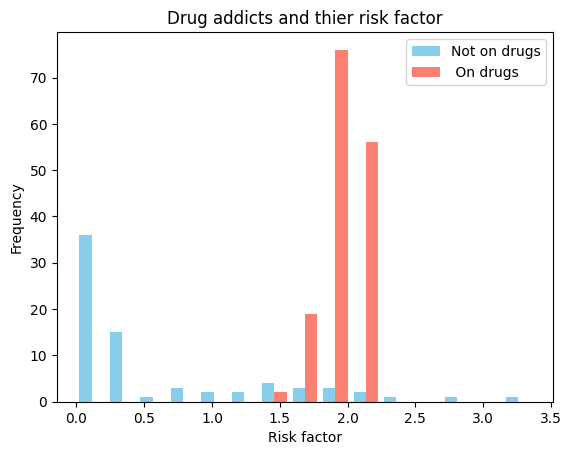

In [ ]:
drug_labels = ['Not on drugs', ' On drugs']

drug_data2 = [drug_test[drug_test['Drug_or_not'] == 0]['Risk_Factor_Score'],
             drug_test[drug_test['Drug_or_not'] == 1]['Risk_Factor_Score']]

plt.hist(drug_data2, bins=15, color=['skyblue', 'salmon'], label=drug_labels)

plt.xlabel('Risk factor')
plt.ylabel('Frequency')
plt.title('Drug addicts and thier risk factor')
plt.legend()

plt.show()

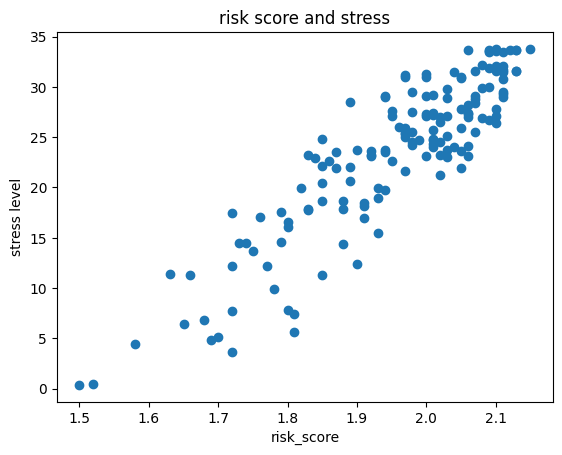

In [ ]:
onDrugs = drug_test[drug_test["Drug_or_not"]== 1]
plt.scatter(onDrugs['Risk_Factor_Score'],onDrugs['Weighted_Stress_Index'] )


plt.xlabel('risk_score')
plt.ylabel('stress level')
plt.title('risk score and stress')


plt.show()


In [ ]:
print("risk factor mean")
print(onDrugs["Risk_Factor_Score"].mean())
print("risk factor range")
print(onDrugs["Risk_Factor_Score"].max()-onDrugs["Risk_Factor_Score"].min())
print("risk factor median ")
print(onDrugs["Risk_Factor_Score"].median())



risk factor mean
1.9533333333333334
risk factor range
0.6499999999999999
risk factor median 
1.98


In [ ]:
print("stress mean")
print(onDrugs["Weighted_Stress_Index"].mean())
print("stress range")
print(onDrugs["Weighted_Stress_Index"].max()-onDrugs["Weighted_Stress_Index"].min())
print("stress median ")
print(onDrugs["Weighted_Stress_Index"].median())


stress mean
23.37333333333333
stress range
33.41
stress median 
24.81


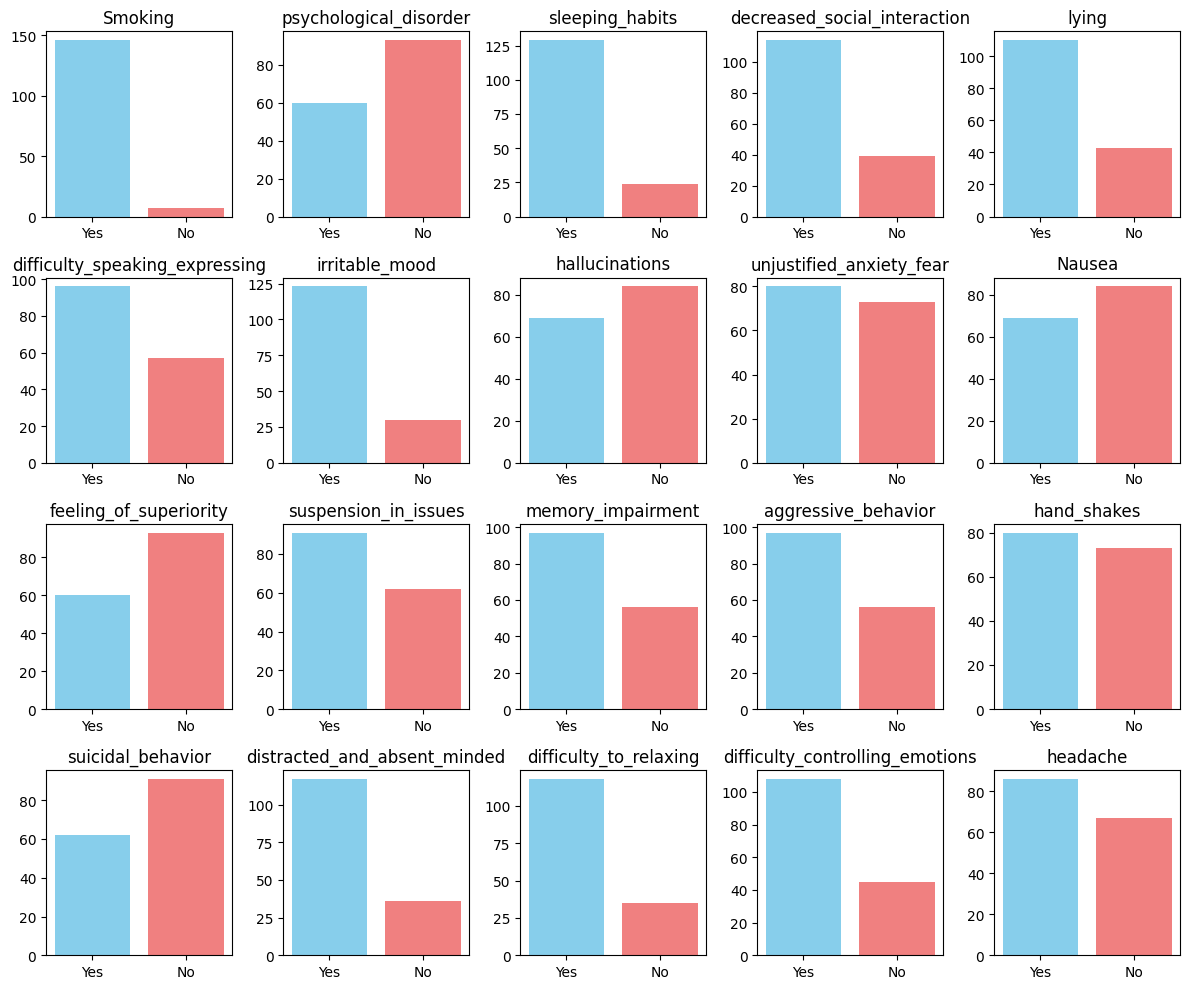

In [ ]:
drug_rows = drug_test[drug_test['Drug_or_not'] == 1]

cat_columns = ['Smoking','psychological_disorder','sleeping_habits','decreased_social_interaction','lying',
                'difficulty_speaking_expressing','irritable_mood','hallucinations','unjustified_anxiety_fear',
                'Nausea','feeling_of_superiority','suspension_in_issues','memory_impairment','aggressive_behavior',
                'hand_shakes','suicidal_behavior','distracted_and_absent_minded','difficulty_to_relaxing',
                'difficulty_controlling_emotions','headache']

fig, axs = plt.subplots(nrows=4, ncols=5, figsize=(12, 10))

axs = axs.flatten()

for i, column in enumerate(cat_columns):

    axs[i].bar(['Yes', 'No'], [drug_rows[column].sum(), len(drug_rows) - drug_rows[column].sum()], color=['skyblue', 'lightcoral'])
    axs[i].set_title(column)

plt.tight_layout()
plt.show()